# Statistics  and  Financial  Data  Analysis



In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from statsmodels.tsa.stattools import adfuller
from numpy.linalg import lstsq
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from arch.univariate import ARX, GARCH, StudentsT, SkewStudent

import sys
sys.path.append("/Users/dnn/Projects")
from stats_libs.timeseries.ts_diagnostics import arima_residual_diagnostics, garch_residual_diagnostics
from stats_libs.timeseries.seasonality import seasonality_diagnostics
from stats_libs.timeseries.stationarity import check_stationarity
from stats_libs.timeseries.seasonality import seasonality_diagnostics
from stats_libs.timeseries.arima_selection import arima_auto_select
from stats_libs.timeseries.garch_selection import arx_garch_auto_select

In [53]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from numpy.linalg import lstsq



In [54]:
# ============================================================
# 2. Jim piecewise-linear model (fixed coefficients)
# ============================================================

K1, K2 = 83.333, 116.667
S0 = 100

iv_jimcoef = {
    0.1: {"b0": 1.0793, "b1": -0.9534, "c1": 0.5250, "c2": 0.8731},
    2.0: {"b0": 0.4389, "b1": -0.2992, "c1": 0.1174, "c2": 0.2129},
}

def jim_pw_predict(x, coef):
    """
    Piecewise-linear in moneyness k = K/S0 with two fixed knots K1, K2.
    """
    x_scaled = x / S0   # k = K/S0
    return (coef["b0"]
            + coef["b1"] * x_scaled
            + coef["c1"] * np.maximum(x_scaled - K1/S0, 0)
            + coef["c2"] * np.maximum(x_scaled - K2/S0, 0))

# ============================================================
# 3. TPB cubic spline helpers
# ============================================================

def tpb_cubic_design(x, knots):
    """
    f(x) = b0 + b1 x + b2 x^2 + b3 x^3 + sum_j c_j (x - k_j)^3_+
    """
    x = np.asarray(x).ravel()
    cols = [np.ones_like(x), x, x**2, x**3]
    for k in knots:
        cols.append(np.maximum(x - k, 0)**3)
    return np.column_stack(cols)

def fit_tpb_cubic(x, y, knots):
    X = tpb_cubic_design(x, knots)
    beta, *_ = lstsq(X, y, rcond=None)
    return beta

def predict_tpb_cubic(x, beta, knots):
    X = tpb_cubic_design(x, knots)
    return X @ beta

def make_knots_from_quantiles(x_train, k):
    """k interior knots at empirical quantiles of x_train."""
    if k <= 0:
        return []
    qs = np.linspace(0, 1, k+2)[1:-1]
    return np.quantile(x_train, qs).tolist()

In [55]:
# ============================================================
# 4. 5-fold CV for TPB cubic (for k=1 and k=6 if needed)
# ============================================================

def kfold_cv_tpb(x, y, k, n_splits=5):
    """
    Returns CV-MSE in *scaled y* space.
    If you want MSE back in original units, rescale by sigma_y^2.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    mse = 0.0
    
    for train_idx, test_idx in kf.split(x):
        x_tr, x_te = x[train_idx], x[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Scale on TRAIN only
        xs = StandardScaler().fit(x_tr.reshape(-1,1))
        ys = StandardScaler().fit(y_tr.reshape(-1,1))

        xs = x_tr
        ys = y_tr

        xs_tr = xs.transform(x_tr.reshape(-1,1)).ravel()
        xs_te = xs.transform(x_te.reshape(-1,1)).ravel()
        ys_tr = ys.transform(y_tr.reshape(-1,1)).ravel()
        ys_te = ys.transform(y_te.reshape(-1,1)).ravel()

        knots = make_knots_from_quantiles(xs_tr, k)
        beta = fit_tpb_cubic(xs_tr, ys_tr, knots)
        yhat = predict_tpb_cubic(xs_te, beta, knots)

        mse += np.mean((ys_te - yhat)**2)

    return mse / n_splits

In [56]:
# ============================================================
# 1. Load datasets
# ============================================================

newq = pd.read_csv("data/newquotes_.csv").sort_values(["maturity", "strike"])
impliedvols = pd.read_csv("data/impliedvols.csv").sort_values(["maturity", "strike"])

T_target = 0.1

train_df = newq[newq["maturity"] == T_target].sort_values("strike")
test_df  = impliedvols[impliedvols["maturity"] == T_target].sort_values("strike")

x_train = train_df["strike"].values
y_train = train_df["implied_vol"].values

x_test = test_df["strike"].values
y_test = test_df["implied_vol"].values

print(f"TRAIN n={len(x_train)}, TEST n={len(x_test)}")

TRAIN n=46, TEST n=11


In [57]:
import numpy as np
import pandas as pd
from numpy.linalg import lstsq

# ============================================================
# 1. Load datasets
# ============================================================

newq = pd.read_csv("data/newquotes_.csv").sort_values(["maturity", "strike"])
impliedvols = pd.read_csv("data/impliedvols.csv").sort_values(["maturity", "strike"])

T_target = 0.1

train_df = newq[newq["maturity"] == T_target].sort_values("strike")
test_df  = impliedvols[impliedvols["maturity"] == T_target].sort_values("strike")

x_train = train_df["strike"].values
y_train = train_df["implied_vol"].values

x_test = test_df["strike"].values
y_test = test_df["implied_vol"].values

print(f"TRAIN n={len(x_train)}, TEST n={len(x_test)}")

# ============================================================
# 2. Jim piecewise-linear model
# ============================================================

K1, K2 = 83.333, 116.667
S0 = 100.0

iv_jimcoef = {
    0.1: {"b0": 1.0793, "b1": -0.9534, "c1": 0.5250, "c2": 0.8731},
    2.0: {"b0": 0.4389, "b1": -0.2992, "c1": 0.1174, "c2": 0.2129},
}

def jim_pw_predict(x, coef):
    """
    Jim's piecewise-linear IV model in moneyness k = K/S0
    f(k) = b0 + b1 k + c1 (k - K1/S0)+ + c2 (k - K2/S0)+
    """
    k = x / S0
    return (coef["b0"]
            + coef["b1"] * k
            + coef["c1"] * np.maximum(k - K1/S0, 0.0)
            + coef["c2"] * np.maximum(k - K2/S0, 0.0))

# ============================================================
# 3. TPB cubic spline helpers
# ============================================================

def tpb_cubic_design(x, knots):
    """
    Truncated power-basis cubic spline:
    f(x) = b0 + b1 x + b2 x^2 + b3 x^3 + sum_j c_j (x - κ_j)^3_+
    """
    x = np.asarray(x).ravel()
    cols = [np.ones_like(x), x, x**2, x**3]
    for k in knots:
        cols.append(np.maximum(x - k, 0.0)**3)
    return np.column_stack(cols)

def fit_tpb_cubic(x, y, knots):
    X = tpb_cubic_design(x, knots)
    beta, *_ = lstsq(X, y, rcond=None)
    return beta

def predict_tpb_cubic(x, beta, knots):
    X = tpb_cubic_design(x, knots)
    return X @ beta

def make_knots_from_quantiles(x_train, k):
    """k interior knots at empirical quantiles of x_train."""
    if k <= 0:
        return []
    qs = np.linspace(0, 1, k + 2)[1:-1]  # drop 0 and 1
    return list(np.quantile(x_train, qs))

# ============================================================
# 4. Metric function (train / test)
# ============================================================

def metrics(y, yhat, p):
    n = len(y)
    resid = y - yhat
    rss = np.sum(resid**2)
    mse = rss / n
    sst = np.sum((y - np.mean(y))**2)

    R2 = 1 - rss/sst
    R2_adj = 1 - (1 - R2) * (n - 1) / (n - p - 1)
    AIC = n * np.log(mse + 1e-12) + 2 * p

    return {"MSE": mse, "AIC": AIC, "R2": R2, "R2_adj": R2_adj}

# ============================================================
# 5. Model 1: Jim PW (no refit, just evaluate)
# ============================================================

coef_jim = iv_jimcoef[T_target]

y_train_pred_jim = jim_pw_predict(x_train, coef_jim)
y_test_pred_jim  = jim_pw_predict(x_test,  coef_jim)

train_m1 = metrics(y_train, y_train_pred_jim, p=4)
test_m1  = metrics(y_test,  y_test_pred_jim,  p=4)

# ============================================================
# 6. Model 2: Cubic spline with 1 fixed knot (Jim's k1)
# ============================================================

# Careful: here k1_cubic is used as a STRIKE knot. If originally defined
# in moneyness, convert via k1_strike = k1_moneyness * S0.
k1_cubic = 1.039 * S0   # if 1.039 was in moneyness; otherwise just 1.039
knots_1 = [k1_cubic]

beta_1 = fit_tpb_cubic(x_train, y_train, knots_1)
y_train_pred_1 = predict_tpb_cubic(x_train, beta_1, knots_1)
y_test_pred_1  = predict_tpb_cubic(x_test,  beta_1, knots_1)

train_m2 = metrics(y_train, y_train_pred_1, p=5)   # 4 poly + 1 knot
test_m2  = metrics(y_test,  y_test_pred_1,  p=5)

# ============================================================
# 7. Model 3: Cubic spline with 6 knots (refit on train)
# ============================================================

k = 6
knots_6 = make_knots_from_quantiles(x_train, k)

beta_6 = fit_tpb_cubic(x_train, y_train, knots_6)
y_train_pred_6 = predict_tpb_cubic(x_train, beta_6, knots_6)
y_test_pred_6  = predict_tpb_cubic(x_test,  beta_6, knots_6)

# p = 4 poly terms + 6 spline terms = 10
train_m3 = metrics(y_train, y_train_pred_6, p=10)
test_m3  = metrics(y_test,  y_test_pred_6,  p=10)

# ============================================================
# 8. Summary table: train vs test + overfitting ratios
# ============================================================

summary = pd.DataFrame({
    "Model": ["Jim PW", "Cubic (1 knot)", "Cubic (6 knots)"],

    "Train_MSE": [train_m1["MSE"], train_m2["MSE"], train_m3["MSE"]],
    "Test_MSE":  [test_m1["MSE"],  test_m2["MSE"],  test_m3["MSE"]],

    "Train_AIC": [train_m1["AIC"], train_m2["AIC"], train_m3["AIC"]],
    "Test_AIC":  [test_m1["AIC"],  test_m2["AIC"],  test_m3["AIC"]],

    "Train_R2":     [train_m1["R2"],     train_m2["R2"],     train_m3["R2"]],
    "Train_R2_adj": [train_m1["R2_adj"], train_m2["R2_adj"], train_m3["R2_adj"]],
    "Test_R2":      [test_m1["R2"],      test_m2["R2"],      test_m3["R2"]],
    "Test_R2_adj":  [test_m1["R2_adj"],  test_m2["R2_adj"],  test_m3["R2_adj"]],

    "Overfit_ratio": [
        test_m1["MSE"] / train_m1["MSE"],
        test_m2["MSE"] / train_m2["MSE"],
        test_m3["MSE"] / train_m3["MSE"],
    ],
})

print("\n=== FINAL TRAIN / TEST SUMMARY (T = 0.1) ===\n")
print(summary.sort_values("Test_AIC", ascending=True))


TRAIN n=46, TEST n=11

=== FINAL TRAIN / TEST SUMMARY (T = 0.1) ===

             Model  Train_MSE  Test_MSE   Train_AIC    Test_AIC   Train_R2  \
2  Cubic (6 knots)   0.000003  0.000001 -567.187965 -127.722960   0.999814   
1   Cubic (1 knot)   0.000319  0.000514 -360.256129  -73.304360   0.979241   
0           Jim PW   0.623500  0.600709  -13.730671    2.393909 -39.522181   

   Train_R2_adj    Test_R2  Test_R2_adj  Overfit_ratio  
2      0.999761   0.999923         -inf       0.514580  
1      0.976646   0.973043     0.946085       1.609499  
0    -43.475565 -30.499738   -51.499564       0.963446  


/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/2612230730.py:91: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2) * (n - 1) / (n - p - 1)



Best model on TEST (by AIC): Cubic (6 knots)


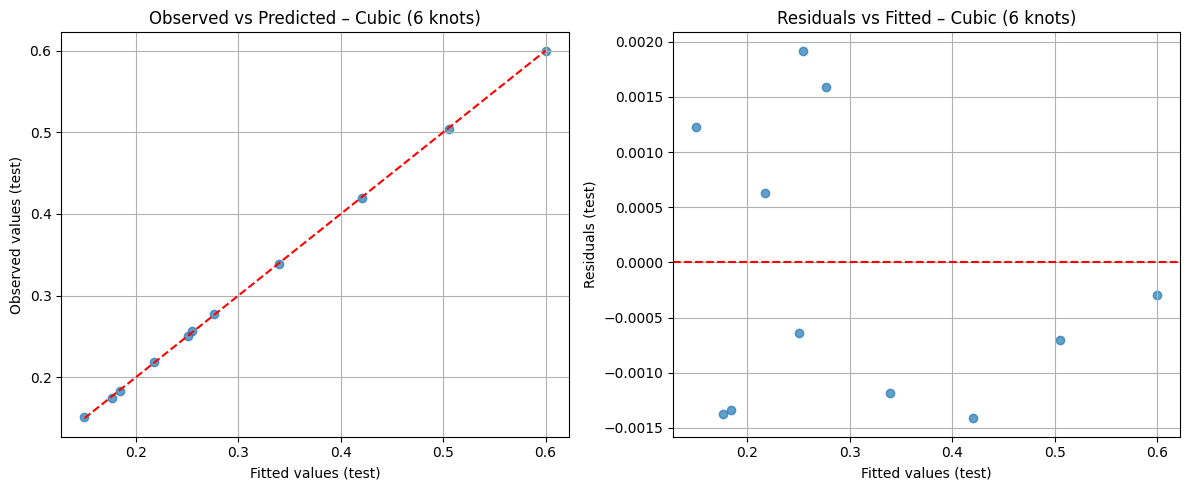

In [59]:
import matplotlib.pyplot as plt

# ============================================================
# 9. Choose the best model (smallest Test AIC)
# ============================================================
best_row = summary.sort_values("Test_AIC").iloc[0]
best_model = best_row["Model"]
print("\nBest model on TEST (by AIC):", best_model)

if best_model == "Jim PW":
    y_test_pred_best = y_test_pred_jim
elif best_model == "Cubic (1 knot)":
    y_test_pred_best = y_test_pred_1
else:  # "Cubic (6 knots)"
    y_test_pred_best = y_test_pred_6

res_test_best = y_test - y_test_pred_best

# ============================================================
# 10. Two-panel figure: Obs vs Pred AND Residuals vs Fitted
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Observed vs Predicted ---
ax = axes[0]
ax.scatter(y_test_pred_best, y_test, alpha=0.7)
lims = [
    min(y_test.min(), y_test_pred_best.min()),
    max(y_test.max(), y_test_pred_best.max())
]
ax.plot(lims, lims, 'r--')
ax.set_xlabel("Fitted values (test)")
ax.set_ylabel("Observed values (test)")
ax.set_title(f"Observed vs Predicted – {best_model}")
ax.grid(True)

# --- Right: Residuals vs Fitted ---
ax = axes[1]
ax.scatter(y_test_pred_best, res_test_best, alpha=0.7)
ax.axhline(0, linestyle='--', color='r')
ax.set_xlabel("Fitted values (test)")
ax.set_ylabel("Residuals (test)")
ax.set_title(f"Residuals vs Fitted – {best_model}")
ax.grid(True)

plt.tight_layout()
plt.show()


In [22]:
# ============================================================
# 1. Load datasets
# ============================================================

newq = pd.read_csv("data/newquotes_.csv").sort_values(["maturity", "strike"])
impliedvols = pd.read_csv("data/impliedvols.csv").sort_values(["maturity", "strike"])

T_target = 2.0

train_df = newq[newq["maturity"] == T_target].sort_values("strike")
test_df  = impliedvols[impliedvols["maturity"] == T_target].sort_values("strike")

x_train = train_df["strike"].values
y_train = train_df["implied_vol"].values

x_test = test_df["strike"].values
y_test = test_df["implied_vol"].values

print(f"TRAIN n={len(x_train)}, TEST n={len(x_test)}")

TRAIN n=47, TEST n=11


In [23]:

# ============================================================
# 5. Metric function
# ============================================================

def metrics(y, yhat, p):
    n = len(y)
    resid = y - yhat
    rss = np.sum(resid**2)
    mse = rss / n
    sst = np.sum((y - np.mean(y))**2)

    R2 = 1 - rss/sst
    R2_adj = 1 - (1 - R2)*(n-1)/(n-p-1)
    AIC = n*np.log(mse + 1e-12) + 2*p

    return {"MSE": mse, "AIC": AIC, "R2": R2, "R2_adj": R2_adj}

# ============================================================
# 6. Model 1: Jim PW (train + test metrics)
# ============================================================

coef_jim = iv_jimcoef[T_target]

y_train_pred_jim = jim_pw_predict(x_train, coef_jim)
y_test_pred_jim  = jim_pw_predict(x_test,  coef_jim)

train_m1 = metrics(y_train, y_train_pred_jim, p=4)
test_m1  = metrics(y_test,  y_test_pred_jim,  p=4)

# ============================================================
# 7. Model 2: Cubic spline with 1 fixed knot (Jim's k1)
# ============================================================

k1_cubic = 1.039   # this is in moneyness in your previous work; here we use it as given
knots_1 = [k1_cubic]

beta_1 = fit_tpb_cubic(x_train, y_train, knots_1)
y_train_pred_1 = predict_tpb_cubic(x_train, beta_1, knots_1)
y_test_pred_1  = predict_tpb_cubic(x_test,  beta_1, knots_1)

train_m2 = metrics(y_train, y_train_pred_1, p=5)
test_m2  = metrics(y_test,  y_test_pred_1,  p=5)

cv_mse_k1 = kfold_cv_tpb(x_train, y_train, k=1)

# ============================================================
# 8. Model 3: Cubic spline with 6 knots (CV-optimal)
# ============================================================

k = 6
knots_6 = make_knots_from_quantiles(x_train, k)

# CV on original train set
cv_mse_k6 = kfold_cv_tpb(x_train, y_train, k)

# Refit full model on train
beta_6 = fit_tpb_cubic(x_train, y_train, knots_6)
y_train_pred_6 = predict_tpb_cubic(x_train, beta_6, knots_6)
y_test_pred_6  = predict_tpb_cubic(x_test,  beta_6, knots_6)

train_m3 = metrics(y_train, y_train_pred_6, p=10)
test_m3  = metrics(y_test,  y_test_pred_6,  p=10)

# ============================================================
# 9. Summary table: train vs test + overfitting ratios
# ============================================================

summary = pd.DataFrame({
    "Model": ["Jim PW", "Cubic (1 knot)", "Cubic (6 knots)"],

    "Train_MSE": [train_m1["MSE"], train_m2["MSE"], train_m3["MSE"]],
    "Test_MSE":  [test_m1["MSE"],  test_m2["MSE"],  test_m3["MSE"]],

    "Train_AIC": [train_m1["AIC"], train_m2["AIC"], train_m3["AIC"]],
    "Test_AIC":  [test_m1["AIC"],  test_m2["AIC"],  test_m3["AIC"]],

    "Train_R2":     [train_m1["R2"],     train_m2["R2"],     train_m3["R2"]],
    "Train_R2_adj": [train_m1["R2_adj"], train_m2["R2_adj"], train_m3["R2_adj"]],
    "Test_R2":      [test_m1["R2"],      test_m2["R2"],      test_m3["R2"]],
    "Test_R2_adj":  [test_m1["R2_adj"],  test_m2["R2_adj"],  test_m3["R2_adj"]],

    "Overfit_ratio": [
        test_m1["MSE"] / train_m1["MSE"],
        test_m2["MSE"] / train_m2["MSE"],
        test_m3["MSE"] / train_m3["MSE"],
    ],

})

print("\n=== FINAL TRAIN / TEST / CV SUMMARY (T = 0.1) ===\n")
summary.sort_values('Test_AIC', ascending=True)



=== FINAL TRAIN / TEST / CV SUMMARY (T = 0.1) ===



/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/754930171.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2)*(n-1)/(n-p-1)


,Model,Train_MSE,Test_MSE,Train_AIC,Test_AIC,Train_R2,Train_R2_adj,Test_R2,Test_R2_adj,Overfit_ratio
2,Cubic (6 knots),1.622406e-10,4.163769e-07,-1039.182420,-141.608398,1.000000,1.000000,0.999854,-inf,2566.416738
1,Cubic (1 knot),3.414788e-07,1.837889e-06,-689.828932,-135.275818,0.999864,0.999847,0.999354,0.998709,5.382146
0,Jim PW,6.834796e-02,6.760180e-02,-118.107746,-21.635327,-26.300488,-28.900535,-22.744816,-38.574693,0.989083


In [60]:
# ============================================================
# Extra imports
# (assume x_train, y_train, x_test, y_test, tpb_cubic_design,
#  make_knots_from_quantiles, metrics are already defined)
# ============================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

# ------------------------------------------------------------------
# Common spline design (baseline): cubic TPB with 6 knots
# ------------------------------------------------------------------
k_baseline = 6
knots6 = make_knots_from_quantiles(x_train, k_baseline)

X_train = tpb_cubic_design(x_train, knots6)
X_test  = tpb_cubic_design(x_test,  knots6)
p_baseline = X_train.shape[1]   # 4 poly + 6 knots = 10

# ============================================================
# 1) Cubic spline OLS (baseline)
# ============================================================
beta_ols, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)
y_train_hat_ols = X_train @ beta_ols
y_test_hat_ols  = X_test  @ beta_ols

m_train_ols = metrics(y_train, y_train_hat_ols, p=p_baseline)
m_test_ols  = metrics(y_test,  y_test_hat_ols,  p=p_baseline)

# ============================================================
# 2) Cubic spline + Ridge (alpha tuned by grid search)
# ============================================================
alphas = np.logspace(-6, 2, 20)
ridge = Ridge(fit_intercept=False)
gscv_ridge = GridSearchCV(ridge,
                          param_grid={"alpha": alphas},
                          cv=5,
                          scoring="neg_mean_squared_error")
gscv_ridge.fit(X_train, y_train)
ridge_best = gscv_ridge.best_estimator_
print("Best alpha (Ridge):", ridge_best.alpha)

y_train_hat_ridge = ridge_best.predict(X_train)
y_test_hat_ridge  = ridge_best.predict(X_test)

m_train_ridge = metrics(y_train, y_train_hat_ridge, p=p_baseline)
m_test_ridge  = metrics(y_test,  y_test_hat_ridge,  p=p_baseline)

# ============================================================
# 3) Cubic spline + Lasso (alpha tuned by grid search)
# ============================================================
lasso = Lasso(fit_intercept=False, max_iter=10000)
gscv_lasso = GridSearchCV(lasso,
                          param_grid={"alpha": alphas},
                          cv=5,
                          scoring="neg_mean_squared_error")
gscv_lasso.fit(X_train, y_train)
lasso_best = gscv_lasso.best_estimator_
print("Best alpha (Lasso):", lasso_best.alpha)

y_train_hat_lasso = lasso_best.predict(X_train)
y_test_hat_lasso  = lasso_best.predict(X_test)

# effective p = number of non-zero coeffs (for AIC)
p_lasso = int(np.sum(lasso_best.coef_ != 0))
m_train_lasso = metrics(y_train, y_train_hat_lasso, p=p_lasso)
m_test_lasso  = metrics(y_test,  y_test_hat_lasso,  p=p_lasso)

# ============================================================
# 4) Cubic spline + GLS (AR(1) errors)
# ============================================================
gls_mod = sm.GLSAR(y_train, X_train, rho=1)
gls_res = gls_mod.iterative_fit(maxiter=10)

y_train_hat_gls = gls_res.fittedvalues
y_test_hat_gls  = gls_res.predict(X_test)

m_train_gls = metrics(y_train, y_train_hat_gls, p=p_baseline)
m_test_gls  = metrics(y_test,  y_test_hat_gls,  p=p_baseline)

# ============================================================
# 5) PCA-basis spline:
#    richer spline (e.g. 12 knots) -> PCA -> OLS on PCs
# ============================================================
k_pca = 12
knots_pca = make_knots_from_quantiles(x_train, k_pca)

X_train_big = tpb_cubic_design(x_train, knots_pca)
X_test_big  = tpb_cubic_design(x_test,  knots_pca)

# keep PCs explaining 90% of variance
pca = PCA(n_components=0.90)
Z_train = pca.fit_transform(X_train_big)
Z_test  = pca.transform(X_test_big)

reg_pc = LinearRegression(fit_intercept=False)
reg_pc.fit(Z_train, y_train)

y_train_hat_pca = reg_pc.predict(Z_train)
y_test_hat_pca  = reg_pc.predict(Z_test)

p_pca = Z_train.shape[1]   # number of components
m_train_pca = metrics(y_train, y_train_hat_pca, p=p_pca)
m_test_pca  = metrics(y_test,  y_test_hat_pca,  p=p_pca)

# ============================================================
# 6) Summary table: train / test MSE + AIC
# ============================================================
summary2 = pd.DataFrame({
    "Model": [
        "Cubic spline (OLS)",
        "Cubic + Ridge",
        "Cubic + Lasso",
        "Cubic + GLS",
        "Cubic + PCA basis",
    ],
    "Train_MSE": [
        m_train_ols["MSE"],
        m_train_ridge["MSE"],
        m_train_lasso["MSE"],
        m_train_gls["MSE"],
        m_train_pca["MSE"],
    ],
    "Test_MSE": [
        m_test_ols["MSE"],
        m_test_ridge["MSE"],
        m_test_lasso["MSE"],
        m_test_gls["MSE"],
        m_test_pca["MSE"],
    ],
    "Train_AIC": [
        m_train_ols["AIC"],
        m_train_ridge["AIC"],
        m_train_lasso["AIC"],
        m_train_gls["AIC"],
        m_train_pca["AIC"],
    ],
    "Test_AIC": [
        m_test_ols["AIC"],
        m_test_ridge["AIC"],
        m_test_lasso["AIC"],
        m_test_gls["AIC"],
        m_test_pca["AIC"],
    ],
})

print("\n=== COMPARISON: CUBIC SPLINE VARIANTS (train/test) ===\n")
print(summary2.sort_values("Test_AIC", ascending=True))


/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/2612230730.py:91: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2) * (n - 1) / (n - p - 1)
/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/2612230730.py:91: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2) * (n - 1) / (n - p - 1)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.954e-04, tolerance: 2.116e-04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations,

Best alpha (Ridge): 2.6366508987303555e-06


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.578e-04, tolerance: 4.257e-04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.973e-04, tolerance: 4.012e-04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

Best alpha (Lasso): 1e-06

=== COMPARISON: CUBIC SPLINE VARIANTS (train/test) ===

                Model  Train_MSE  Test_MSE   Train_AIC    Test_AIC
0  Cubic spline (OLS)   0.000003  0.000001 -567.187965 -127.722960
3         Cubic + GLS   0.000003  0.000003 -565.418572 -119.872925
1       Cubic + Ridge   0.000013  0.000012 -498.689373 -104.980439
2       Cubic + Lasso   0.000034  0.000052 -457.979084  -92.592576
4   Cubic + PCA basis   0.093466  0.109270 -107.027109  -22.353312


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.979e-04, tolerance: 4.012e-04
  model = cd_fast.enet_coordinate_descent(
/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/2612230730.py:91: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2) * (n - 1) / (n - p - 1)


# New model

In [24]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge

import statsmodels.api as sm
from numpy.linalg import lstsq

# ============================================================
# 1. Load datasets and build train / test for T = 0.1
# ============================================================

newq = pd.read_csv("data/newquotes_.csv").sort_values(["maturity", "strike"])
impliedvols = pd.read_csv("data/impliedvols.csv").sort_values(["maturity", "strike"])

T_target = 0.1

train_df = newq[newq["maturity"] == T_target].sort_values("strike")
test_df  = impliedvols[impliedvols["maturity"] == T_target].sort_values("strike")

x_train = train_df["strike"].values
y_train = train_df["implied_vol"].values

x_test = test_df["strike"].values
y_test = test_df["implied_vol"].values

print(f"TRAIN n = {len(x_train)}, TEST n = {len(x_test)}")

# ============================================================
# 2. Common helpers: Jim PW + TPB cubic + metrics
# ============================================================

K1, K2 = 83.333, 116.667
S0 = 100

iv_jimcoef = {
    0.1: {"b0": 1.0793, "b1": -0.9534, "c1": 0.5250, "c2": 0.8731},
    2.0: {"b0": 0.4389, "b1": -0.2992, "c1": 0.1174, "c2": 0.2129},
}

def jim_pw_predict(x, coef):
    """
    Jim piecewise-linear model in moneyness k = K/S0 with two fixed knots K1, K2.
    """
    x_scaled = x / S0
    return (coef["b0"]
            + coef["b1"] * x_scaled
            + coef["c1"] * np.maximum(x_scaled - K1/S0, 0)
            + coef["c2"] * np.maximum(x_scaled - K2/S0, 0))

def tpb_cubic_design(x, knots):
    """
    Truncated power basis cubic spline:
    f(x) = b0 + b1 x + b2 x^2 + b3 x^3 + sum_j c_j (x - k_j)^3_+
    """
    x = np.asarray(x).ravel()
    cols = [np.ones_like(x), x, x**2, x**3]
    for k in knots:
        cols.append(np.maximum(x - k, 0)**3)
    return np.column_stack(cols)

def fit_tpb_cubic(x, y, knots):
    X = tpb_cubic_design(x, knots)
    beta, *_ = lstsq(X, y, rcond=None)
    return beta

def predict_tpb_cubic(x, beta, knots):
    X = tpb_cubic_design(x, knots)
    return X @ beta

def make_knots_from_quantiles(x_train, k):
    """
    Choose k interior knots at empirical quantiles of x_train.
    """
    if k <= 0:
        return []
    qs = np.linspace(0, 1, k+2)[1:-1]
    return np.quantile(x_train, qs).tolist()

def metrics(y, yhat, p):
    """
    MSE, AIC, R², R² adj. p = nb de paramètres du modèle.
    """
    n = len(y)
    resid = y - yhat
    rss = np.sum(resid**2)
    mse = rss / n
    sst = np.sum((y - np.mean(y))**2)

    R2 = 1 - rss/sst
    R2_adj = 1 - (1 - R2)*(n-1)/(n-p-1)
    AIC = n * np.log(mse + 1e-12) + 2 * p

    return {"MSE": mse, "AIC": AIC, "R2": R2, "R2_adj": R2_adj}

# ============================================================
# 3. Benchmark models: Jim PW, Cubic 1 knot (OLS), Cubic 6 knots (OLS)
# ============================================================

coef_jim = iv_jimcoef[T_target]

# --- Model 1: Jim PW (no refit)
y_test_pred_jim = jim_pw_predict(x_test, coef_jim)
test_m1 = metrics(y_test, y_test_pred_jim, p=4)

# --- Model 2: TPB cubic with 1 fixed knot (Jim's k1)
k1_cubic = 1.039
knots_1 = [k1_cubic]

beta_1 = fit_tpb_cubic(x_train, y_train, knots_1)
y_test_pred_1 = predict_tpb_cubic(x_test, beta_1, knots_1)
test_m2 = metrics(y_test, y_test_pred_1, p=5)

# --- Model 3: TPB cubic with 6 knots (OLS)
k = 6
knots_6 = make_knots_from_quantiles(x_train, k)

beta_6 = fit_tpb_cubic(x_train, y_train, knots_6)
y_test_pred_6 = predict_tpb_cubic(x_test, beta_6, knots_6)
test_m3 = metrics(y_test, y_test_pred_6, p=10)

# Design matrices for models based on 6 knots (for Ridge / Lasso / GLS)
X_train_6 = tpb_cubic_design(x_train, knots_6)
X_test_6  = tpb_cubic_design(x_test,  knots_6)
p_6 = X_train_6.shape[1]  # should be 10

# ============================================================
# 4. Ridge regression on TPB cubic (6 knots)
# ============================================================

# Standardize predictors for ridge (common practice)
X_scaler = StandardScaler().fit(X_train_6)
X_train_6_sc = X_scaler.transform(X_train_6)
X_test_6_sc  = X_scaler.transform(X_test_6)

# Small CV over alphas for Ridge
alphas_ridge = [1e-6, 1e-4, 1e-2, 1e0, 1e2]
kf = KFold(n_splits=5, shuffle=True, random_state=0)

best_alpha_ridge = None
best_cv_mse_ridge = np.inf

for a in alphas_ridge:
    cv_mse = 0.0
    for tr_idx, val_idx in kf.split(X_train_6_sc):
        X_tr, X_val = X_train_6_sc[tr_idx], X_train_6_sc[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = Ridge(alpha=a, fit_intercept=False)  # intercept already in design
        model.fit(X_tr, y_tr)
        yhat_val = model.predict(X_val)
        cv_mse += np.mean((y_val - yhat_val)**2)
    cv_mse /= kf.get_n_splits()

    if cv_mse < best_cv_mse_ridge:
        best_cv_mse_ridge = cv_mse
        best_alpha_ridge = a

print(f"Best Ridge alpha = {best_alpha_ridge}, CV MSE ≈ {best_cv_mse_ridge:.4e}")

ridge_model = Ridge(alpha=best_alpha_ridge, fit_intercept=False)
ridge_model.fit(X_train_6_sc, y_train)
y_test_pred_ridge = ridge_model.predict(X_test_6_sc)
test_m_ridge = metrics(y_test, y_test_pred_ridge, p=p_6)

# ============================================================
# 5. Lasso regression on TPB cubic (6 knots)
# ============================================================

alphas_lasso = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
best_alpha_lasso = None
best_cv_mse_lasso = np.inf

for a in alphas_lasso:
    cv_mse = 0.0
    for tr_idx, val_idx in kf.split(X_train_6_sc):
        X_tr, X_val = X_train_6_sc[tr_idx], X_train_6_sc[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = Lasso(alpha=a, fit_intercept=False, max_iter=10000)
        model.fit(X_tr, y_tr)
        yhat_val = model.predict(X_val)
        cv_mse += np.mean((y_val - yhat_val)**2)
    cv_mse /= kf.get_n_splits()

    if cv_mse < best_cv_mse_lasso:
        best_cv_mse_lasso = cv_mse
        best_alpha_lasso = a

print(f"Best Lasso alpha = {best_alpha_lasso}, CV MSE ≈ {best_cv_mse_lasso:.4e}")

lasso_model = Lasso(alpha=best_alpha_lasso, fit_intercept=False, max_iter=10000)
lasso_model.fit(X_train_6_sc, y_train)
y_test_pred_lasso = lasso_model.predict(X_test_6_sc)
test_m_lasso = metrics(y_test, y_test_pred_lasso, p=p_6)  # on garde p=10 pour comparaison

# ============================================================
# 6. GLS with AR(1) errors on TPB cubic (6 knots)
# ============================================================

# Here we treat strikes as an ordered "index" and assume AR(1) correlation in residuals.
gls_model = sm.GLSAR(y_train, X_train_6, rho=1)
gls_res = gls_model.iterative_fit(maxiter=10)

y_test_pred_gls = gls_res.predict(X_test_6)
test_m_gls = metrics(y_test, y_test_pred_gls, p=p_6)

# ============================================================
# 7. Gaussian kernel ridge regression (RBF)
# ============================================================

# We'll do 1D KernelRidge on strike only, with simple CV for (alpha, gamma)
X_train_1d = x_train.reshape(-1, 1)
X_test_1d  = x_test.reshape(-1, 1)

sigma_x = np.std(x_train)
gammas = [0.1/(sigma_x**2), 1.0/(sigma_x**2), 10.0/(sigma_x**2)]
alphas_kr = [1e-6, 1e-4, 1e-2, 1e0]

best_alpha_kr = None
best_gamma_kr = None
best_cv_mse_kr = np.inf

for g in gammas:
    for a in alphas_kr:
        cv_mse = 0.0
        for tr_idx, val_idx in kf.split(X_train_1d):
            X_tr, X_val = X_train_1d[tr_idx], X_train_1d[val_idx]
            y_tr, y_val = y_train[tr_idx], y_train[val_idx]

            kr = KernelRidge(kernel="rbf", alpha=a, gamma=g)
            kr.fit(X_tr, y_tr)
            yhat_val = kr.predict(X_val)
            cv_mse += np.mean((y_val - yhat_val)**2)
        cv_mse /= kf.get_n_splits()

        if cv_mse < best_cv_mse_kr:
            best_cv_mse_kr = cv_mse
            best_alpha_kr = a
            best_gamma_kr = g

print(f"Best KernelRidge alpha = {best_alpha_kr}, gamma = {best_gamma_kr}, CV MSE ≈ {best_cv_mse_kr:.4e}")

kr_best = KernelRidge(kernel="rbf", alpha=best_alpha_kr, gamma=best_gamma_kr)
kr_best.fit(X_train_1d, y_train)
y_test_pred_kr = kr_best.predict(X_test_1d)

# Pour l'AIC, on prend p ≈ 10 par analogie avec le spline 6 knots
test_m_kr = metrics(y_test, y_test_pred_kr, p=10)

# ============================================================
# 8. Final comparison table (only TEST metrics + sort by Test AIC)
# ============================================================

results_test = pd.DataFrame([
    {
        "Model": "Jim PW",
        "Test_MSE": test_m1["MSE"],
        "Test_AIC": test_m1["AIC"],
        "Test_R2": test_m1["R2"],
        "Test_R2_adj": test_m1["R2_adj"],
    },
    {
        "Model": "Cubic (1 knot) OLS",
        "Test_MSE": test_m2["MSE"],
        "Test_AIC": test_m2["AIC"],
        "Test_R2": test_m2["R2"],
        "Test_R2_adj": test_m2["R2_adj"],
    },
    {
        "Model": "Cubic (6 knots) OLS",
        "Test_MSE": test_m3["MSE"],
        "Test_AIC": test_m3["AIC"],
        "Test_R2": test_m3["R2"],
        "Test_R2_adj": test_m3["R2_adj"],
    },
    {
        "Model": "Cubic (6 knots) Ridge",
        "Test_MSE": test_m_ridge["MSE"],
        "Test_AIC": test_m_ridge["AIC"],
        "Test_R2": test_m_ridge["R2"],
        "Test_R2_adj": test_m_ridge["R2_adj"],
    },
    {
        "Model": "Cubic (6 knots) Lasso",
        "Test_MSE": test_m_lasso["MSE"],
        "Test_AIC": test_m_lasso["AIC"],
        "Test_R2": test_m_lasso["R2"],
        "Test_R2_adj": test_m_lasso["R2_adj"],
    },
    {
        "Model": "Cubic (6 knots) GLS(AR1)",
        "Test_MSE": test_m_gls["MSE"],
        "Test_AIC": test_m_gls["AIC"],
        "Test_R2": test_m_gls["R2"],
        "Test_R2_adj": test_m_gls["R2_adj"],
    },
    {
        "Model": "Gaussian Kernel Ridge",
        "Test_MSE": test_m_kr["MSE"],
        "Test_AIC": test_m_kr["AIC"],
        "Test_R2": test_m_kr["R2"],
        "Test_R2_adj": test_m_kr["R2_adj"],
    },
])

results_test_sorted = results_test.sort_values("Test_AIC").reset_index(drop=True)

print("\n=== TEST-SET COMPARISON (sorted by Test_AIC ascending) ===\n")
print(results_test_sorted.round(8))


TRAIN n = 46, TEST n = 11
Best Ridge alpha = 100.0, CV MSE ≈ 9.9328e-02
Best Lasso alpha = 0.1, CV MSE ≈ 9.9838e-02
Best KernelRidge alpha = 0.0001, gamma = 12.533333333333305, CV MSE ≈ 3.7660e-06

=== TEST-SET COMPARISON (sorted by Test_AIC ascending) ===

                      Model  Test_MSE    Test_AIC    Test_R2  Test_R2_adj
0       Cubic (6 knots) OLS  0.000001 -127.722960   0.999923         -inf
1     Gaussian Kernel Ridge  0.000002 -123.788021   0.999890         -inf
2  Cubic (6 knots) GLS(AR1)  0.000003 -119.872925   0.999842         -inf
3        Cubic (1 knot) OLS  0.000119  -89.401909   0.993761     0.987522
4     Cubic (6 knots) Ridge  0.102649   -5.040809  -4.382681         -inf
5     Cubic (6 knots) Lasso  0.113139   -3.970565  -4.932713         -inf
6                    Jim PW  0.600709    2.393909 -30.499738   -51.499564


/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/686376232.py:94: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2)*(n-1)/(n-p-1)
/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/686376232.py:94: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2)*(n-1)/(n-p-1)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.821e-01, tolerance: 3.806e-04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of th

In [51]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge, Lasso

import statsmodels.api as sm
from numpy.linalg import lstsq

# ============================================================
# 1. Load datasets and build train / test for T = 0.1
# ============================================================

newq = pd.read_csv("data/newquotes_.csv").sort_values(["maturity", "strike"])
impliedvols = pd.read_csv("data/impliedvols.csv").sort_values(["maturity", "strike"])

T_target = 0.1

train_df = newq[newq["maturity"] == T_target].sort_values("strike")
test_df  = impliedvols[impliedvols["maturity"] == T_target].sort_values("strike")

x_train = train_df["strike"].values
y_train = train_df["implied_vol"].values

x_test = test_df["strike"].values
y_test = test_df["implied_vol"].values

print(f"TRAIN n = {len(x_train)}, TEST n = {len(x_test)}")

# ============================================================
# 2. Common helpers: Jim PW + TPB cubic + metrics
# ============================================================

K1, K2 = 83.333, 116.667
S0 = 100

iv_jimcoef = {
    0.1: {"b0": 1.0793, "b1": -0.9534, "c1": 0.5250, "c2": 0.8731},
    2.0: {"b0": 0.4389, "b1": -0.2992, "c1": 0.1174, "c2": 0.2129},
}

def jim_pw_predict(x, coef):
    """
    Jim piecewise-linear model in moneyness k = K/S0 with two fixed knots K1, K2.
    """
    x_scaled = x / S0
    return (coef["b0"]
            + coef["b1"] * x_scaled
            + coef["c1"] * np.maximum(x_scaled - K1/S0, 0)
            + coef["c2"] * np.maximum(x_scaled - K2/S0, 0))

def tpb_cubic_design(x, knots):
    """
    Truncated power basis cubic spline:
    f(x) = b0 + b1 x + b2 x^2 + b3 x^3 + sum_j c_j (x - k_j)^3_+
    """
    x = np.asarray(x).ravel()
    cols = [np.ones_like(x), x, x**2, x**3]
    for k in knots:
        cols.append(np.maximum(x - k, 0)**3)
    return np.column_stack(cols)

def fit_tpb_cubic(x, y, knots):
    X = tpb_cubic_design(x, knots)
    beta, *_ = lstsq(X, y, rcond=None)
    return beta

def predict_tpb_cubic(x, beta, knots):
    X = tpb_cubic_design(x, knots)
    return X @ beta

def make_knots_from_quantiles(x_train, k):
    """
    Choose k interior knots at empirical quantiles of x_train.
    """
    if k <= 0:
        return []
    qs = np.linspace(0, 1, k+2)[1:-1]
    return np.quantile(x_train, qs).tolist()

def metrics(y, yhat, p):
    """
    MSE, AIC, R², R² adj. p = nb de paramètres du modèle.
    """
    n = len(y)
    resid = y - yhat
    rss = np.sum(resid**2)
    mse = rss / n
    sst = np.sum((y - np.mean(y))**2)

    R2 = 1 - rss/sst
    R2_adj = 1 - (1 - R2)*(n-1)/(n-p-1)
    AIC = n * np.log(mse + 1e-12) + 2 * p

    return {"MSE": mse, "AIC": AIC, "R2": R2, "R2_adj": R2_adj}

# ============================================================
# 3. Benchmark models: Jim PW, Cubic 1 knot (OLS), Cubic 6 knots (OLS)
# ============================================================

coef_jim = iv_jimcoef[T_target]

# --- Model 1: Jim PW (no refit)
y_test_pred_jim = jim_pw_predict(x_test, coef_jim)
test_m1 = metrics(y_test, y_test_pred_jim, p=4)

# --- Model 2: TPB cubic with 1 fixed knot (Jim's k1)
k1_cubic = 1.039
knots_1 = [k1_cubic]

beta_1 = fit_tpb_cubic(x_train, y_train, knots_1)
y_test_pred_1 = predict_tpb_cubic(x_test, beta_1, knots_1)
test_m2 = metrics(y_test, y_test_pred_1, p=5)

# --- Model 3: TPB cubic with 6 knots (OLS)
k = 6
knots_6 = make_knots_from_quantiles(x_train, k)

beta_6 = fit_tpb_cubic(x_train, y_train, knots_6)
y_test_pred_6 = predict_tpb_cubic(x_test, beta_6, knots_6)
test_m3 = metrics(y_test, y_test_pred_6, p=10)

# Design matrices for models based on 6 knots (for Ridge / Lasso / GLS)
X_train_6 = tpb_cubic_design(x_train, knots_6)
X_test_6  = tpb_cubic_design(x_test,  knots_6)
p_6 = X_train_6.shape[1]  # should be 10

# ============================================================
# 4. Ridge regression on TPB cubic (6 knots)
# ============================================================

# Standardize predictors for ridge / lasso
X_scaler = StandardScaler().fit(X_train_6)
X_train_6_sc = X_scaler.transform(X_train_6)
X_test_6_sc  = X_scaler.transform(X_test_6)

kf = KFold(n_splits=5, shuffle=True, random_state=0)

alphas_ridge = [1e-8, 1e-6, 1e-4, 1e-2, 1e0]
best_alpha_ridge = None
best_cv_mse_ridge = np.inf

for a in alphas_ridge:
    cv_mse = 0.0
    for tr_idx, val_idx in kf.split(X_train_6_sc):
        X_tr, X_val = X_train_6_sc[tr_idx], X_train_6_sc[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = Ridge(alpha=a, fit_intercept=False)  # intercept already in design
        model.fit(X_tr, y_tr)
        yhat_val = model.predict(X_val)
        cv_mse += np.mean((y_val - yhat_val)**2)
    cv_mse /= kf.get_n_splits()

    if cv_mse < best_cv_mse_ridge:
        best_cv_mse_ridge = cv_mse
        best_alpha_ridge = a

print(f"Best Ridge alpha = {best_alpha_ridge}, CV MSE ≈ {best_cv_mse_ridge:.4e}")

ridge_model = Ridge(alpha=best_alpha_ridge, fit_intercept=False)
ridge_model.fit(X_train_6_sc, y_train)
y_test_pred_ridge = ridge_model.predict(X_test_6_sc)
test_m_ridge = metrics(y_test, y_test_pred_ridge, p=p_6)

# ============================================================
# 5. Lasso regression on TPB cubic (6 knots) with much smaller alphas
# ============================================================

# Very small alphas: just a light L1 penalty
alphas_lasso = [1e-8, 3e-8, 1e-7, 3e-7, 1e-6, 3e-6, 1e-5, 3e-5, 1e-4]
best_alpha_lasso = None
best_cv_mse_lasso = np.inf

for a in alphas_lasso:
    cv_mse = 0.0
    for tr_idx, val_idx in kf.split(X_train_6_sc):
        X_tr, X_val = X_train_6_sc[tr_idx], X_train_6_sc[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = Lasso(alpha=a, fit_intercept=False, max_iter=100000)
        model.fit(X_tr, y_tr)
        yhat_val = model.predict(X_val)
        cv_mse += np.mean((y_val - yhat_val)**2)
    cv_mse /= kf.get_n_splits()

    if cv_mse < best_cv_mse_lasso:
        best_cv_mse_lasso = cv_mse
        best_alpha_lasso = a

print(f"Best Lasso alpha = {best_alpha_lasso}, CV MSE ≈ {best_cv_mse_lasso:.4e}")

lasso_model = Lasso(alpha=best_alpha_lasso, fit_intercept=False, max_iter=100000)
lasso_model.fit(X_train_6_sc, y_train)
y_test_pred_lasso = lasso_model.predict(X_test_6_sc)
test_m_lasso = metrics(y_test, y_test_pred_lasso, p=p_6)  # p=10 for comparability

# ============================================================
# 6. GLS with AR(1) errors on TPB cubic (6 knots)
# ============================================================

gls_model = sm.GLSAR(y_train, X_train_6, rho=1)
gls_res = gls_model.iterative_fit(maxiter=10)

y_test_pred_gls = gls_res.predict(X_test_6)
test_m_gls = metrics(y_test, y_test_pred_gls, p=p_6)

# ============================================================
# 7. RBF kernel features + Ridge and GLS
# ============================================================

def rbf_features(x, centers, gamma):
    """
    Explicit RBF feature map φ_j(x) = exp(-γ (x - c_j)^2).
    x: (n,)
    centers: (m,)
    return: (n, m)
    """
    x = x.reshape(-1, 1)
    centers = centers.reshape(1, -1)
    return np.exp(-gamma * (x - centers)**2)

# choose RBF centres as quantiles of strike (e.g. 10 centres)
n_centers = 10
centers = np.quantile(x_train, np.linspace(0, 1, n_centers))

# CV over gamma and alpha for Ridge in RBF space
sigma_x = np.std(x_train)
gammas = [0.1/(sigma_x**2), 1.0/(sigma_x**2), 10.0/(sigma_x**2)]
alphas_rbf_ridge = [1e-8, 1e-6, 1e-4, 1e-2]

best_gamma_rbf = None
best_alpha_rbf = None
best_cv_mse_rbf = np.inf

for g in gammas:
    Phi_train = rbf_features(x_train, centers, g)
    # add intercept
    Phi_train_design = np.column_stack([np.ones(len(x_train)), Phi_train])

    # standardise features for ridge
    scaler_rbf = StandardScaler().fit(Phi_train_design)
    Phi_train_sc = scaler_rbf.transform(Phi_train_design)

    for a in alphas_rbf_ridge:
        cv_mse = 0.0
        for tr_idx, val_idx in kf.split(Phi_train_sc):
            X_tr, X_val = Phi_train_sc[tr_idx], Phi_train_sc[val_idx]
            y_tr, y_val = y_train[tr_idx], y_train[val_idx]

            model = Ridge(alpha=a, fit_intercept=False)
            model.fit(X_tr, y_tr)
            yhat_val = model.predict(X_val)
            cv_mse += np.mean((y_val - yhat_val)**2)
        cv_mse /= kf.get_n_splits()

        if cv_mse < best_cv_mse_rbf:
            best_cv_mse_rbf = cv_mse
            best_gamma_rbf = g
            best_alpha_rbf = a

print(f"Best RBF-Ridge: gamma = {best_gamma_rbf}, alpha = {best_alpha_rbf}, CV MSE ≈ {best_cv_mse_rbf:.4e}")

# Refit RBF+Ridge on full train
Phi_train_best = rbf_features(x_train, centers, best_gamma_rbf)
Phi_train_design = np.column_stack([np.ones(len(x_train)), Phi_train_best])

scaler_rbf = StandardScaler().fit(Phi_train_design)
Phi_train_sc = scaler_rbf.transform(Phi_train_design)

ridge_rbf = Ridge(alpha=best_alpha_rbf, fit_intercept=False)
ridge_rbf.fit(Phi_train_sc, y_train)

# Test features
Phi_test_best = rbf_features(x_test, centers, best_gamma_rbf)
Phi_test_design = np.column_stack([np.ones(len(x_test)), Phi_test_best])
Phi_test_sc = scaler_rbf.transform(Phi_test_design)

y_test_pred_rbf_ridge = ridge_rbf.predict(Phi_test_sc)
p_rbf = Phi_train_design.shape[1]  # nb of coeffs (1 + n_centers)
test_m_rbf_ridge = metrics(y_test, y_test_pred_rbf_ridge, p=p_rbf)

# --- RBF + GLS(AR1) ---

# Use same gamma but GLSAR instead of Ridge (no explicit penalty here)
Phi_train_gls = Phi_train_design  # same as above (intercept + RBFs)
Phi_test_gls  = Phi_test_design

gls_rbf_model = sm.GLSAR(y_train, Phi_train_gls, rho=1)
gls_rbf_res = gls_rbf_model.iterative_fit(maxiter=10)

y_test_pred_rbf_gls = gls_rbf_res.predict(Phi_test_gls)
test_m_rbf_gls = metrics(y_test, y_test_pred_rbf_gls, p=p_rbf)

# ============================================================
# 8. Final comparison table (only TEST metrics + sort by Test AIC)
# ============================================================

results_test = pd.DataFrame([
    {
        "Model": "Jim PW",
        "Test_MSE": test_m1["MSE"],
        "Test_AIC": test_m1["AIC"],
        "Test_R2": test_m1["R2"],
        "Test_R2_adj": test_m1["R2_adj"],
    },
    {
        "Model": "Cubic (1 knot) OLS",
        "Test_MSE": test_m2["MSE"],
        "Test_AIC": test_m2["AIC"],
        "Test_R2": test_m2["R2"],
        "Test_R2_adj": test_m2["R2_adj"],
    },
    {
        "Model": "Cubic (6 knots) OLS",
        "Test_MSE": test_m3["MSE"],
        "Test_AIC": test_m3["AIC"],
        "Test_R2": test_m3["R2"],
        "Test_R2_adj": test_m3["R2_adj"],
    },
    {
        "Model": "Cubic (6 knots) Ridge",
        "Test_MSE": test_m_ridge["MSE"],
        "Test_AIC": test_m_ridge["AIC"],
        "Test_R2": test_m_ridge["R2"],
        "Test_R2_adj": test_m_ridge["R2_adj"],
    },
    {
        "Model": "Cubic (6 knots) Lasso",
        "Test_MSE": test_m_lasso["MSE"],
        "Test_AIC": test_m_lasso["AIC"],
        "Test_R2": test_m_lasso["R2"],
        "Test_R2_adj": test_m_lasso["R2_adj"],
    },
    {
        "Model": "Cubic (6 knots) GLS(AR1)",
        "Test_MSE": test_m_gls["MSE"],
        "Test_AIC": test_m_gls["AIC"],
        "Test_R2": test_m_gls["R2"],
        "Test_R2_adj": test_m_gls["R2_adj"],
    },
    {
        "Model": "RBF + Ridge",
        "Test_MSE": test_m_rbf_ridge["MSE"],
        "Test_AIC": test_m_rbf_ridge["AIC"],
        "Test_R2": test_m_rbf_ridge["R2"],
        "Test_R2_adj": test_m_rbf_ridge["R2_adj"],
    },
    {
        "Model": "RBF + GLS(AR1)",
        "Test_MSE": test_m_rbf_gls["MSE"],
        "Test_AIC": test_m_rbf_gls["AIC"],
        "Test_R2": test_m_rbf_gls["R2"],
        "Test_R2_adj": test_m_rbf_gls["R2_adj"],
    },
])

results_test_sorted = results_test.sort_values("Test_AIC").reset_index(drop=True)

print("\n=== TEST-SET COMPARISON (sorted by Test_AIC ascending) ===\n")
print(results_test_sorted.round(8))


TRAIN n = 46, TEST n = 11
Best Ridge alpha = 1.0, CV MSE ≈ 1.0749e-01


/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/3052613006.py:93: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2)*(n-1)/(n-p-1)
/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/3052613006.py:93: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2)*(n-1)/(n-p-1)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.381e+00, tolerance: 3.806e-04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of 

Best Lasso alpha = 0.0001, CV MSE ≈ 1.2598e-01
Best RBF-Ridge: gamma = 1.2533333333333305, alpha = 0.01, CV MSE ≈ 9.4828e-02

=== TEST-SET COMPARISON (sorted by Test_AIC ascending) ===

                      Model  Test_MSE    Test_AIC    Test_R2  Test_R2_adj
0       Cubic (6 knots) OLS  0.000001 -127.722960   0.999923         -inf
1  Cubic (6 knots) GLS(AR1)  0.000003 -119.872925   0.999842         -inf
2        Cubic (1 knot) OLS  0.000119  -89.401909   0.993761     0.987522
3            RBF + GLS(AR1)  0.000200  -71.671389   0.989496     1.105044
4     Cubic (6 knots) Lasso  0.083722   -7.282850  -3.390156         -inf
5     Cubic (6 knots) Ridge  0.087095   -6.848291  -3.567062         -inf
6               RBF + Ridge  0.082851   -5.397760  -3.344533    44.445333
7                    Jim PW  0.600709    2.393909 -30.499738   -51.499564


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.330e-03, tolerance: 3.551e-04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.532e-03, tolerance: 3.458e-04
  model = cd_fast.enet_coordinate_descent(
/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/3052613006.py:93: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2)*(n-1)/(n-p-1)


T = 0.1, n_T = 46
Baseline TPB cubic (k=6) 5-fold CV MSE = 5.650129e-06
Rich TPB design: k_rich = 20, p = 24 predictors

Grid-search PCA+Ridge (5-fold CV)...

n_comp =  2, alpha = 1.0e-08, CV_MSE = 1.010636e-01
n_comp =  2, alpha = 1.0e-06, CV_MSE = 1.010636e-01
n_comp =  2, alpha = 1.0e-04, CV_MSE = 1.010635e-01
n_comp =  2, alpha = 1.0e-02, CV_MSE = 1.010610e-01
n_comp =  2, alpha = 1.0e-01, CV_MSE = 1.010382e-01
n_comp =  3, alpha = 1.0e-08, CV_MSE = 1.451680e-01
n_comp =  3, alpha = 1.0e-06, CV_MSE = 1.451679e-01
n_comp =  3, alpha = 1.0e-04, CV_MSE = 1.451673e-01
n_comp =  3, alpha = 1.0e-02, CV_MSE = 1.451047e-01
n_comp =  3, alpha = 1.0e-01, CV_MSE = 1.445399e-01
n_comp =  4, alpha = 1.0e-08, CV_MSE = 9.705846e-02
n_comp =  4, alpha = 1.0e-06, CV_MSE = 9.705845e-02
n_comp =  4, alpha = 1.0e-04, CV_MSE = 9.705727e-02
n_comp =  4, alpha = 1.0e-02, CV_MSE = 9.693977e-02
n_comp =  4, alpha = 1.0e-01, CV_MSE = 9.591405e-02
n_comp =  5, alpha = 1.0e-08, CV_MSE = 9.228778e-02
n_comp = 

In [38]:
newq = pd.read_csv("data/newquotes_.csv").sort_values(["maturity", "strike"])
impliedvols = pd.read_csv("data/impliedvols.csv").sort_values(["maturity", "strike"])

T_target = 0.1

train_df = newq[newq["maturity"] == T_target].sort_values("strike")
test_df  = impliedvols[impliedvols["maturity"] == T_target].sort_values("strike")

test_df

,maturity,strike,implied_vol
0,0.1,0.5,0.599623
1,0.1,0.6,0.504592
2,0.1,0.7,0.419024
3,0.1,0.8,0.338254
4,0.1,0.9,0.256693
5,0.1,1.0,0.175175
6,0.1,1.1,0.150950
7,0.1,1.2,0.183043
8,0.1,1.3,0.218290
9,0.1,1.4,0.250023


In [39]:
train_df['implied_vol'].corr(test_df['implied_vol'])

0.7745075214365825

In [40]:
train_df

,maturity,strike,implied_vol
0,0.1,0.521277,0.578289
1,0.1,0.542553,0.559852
2,0.1,0.563830,0.537841
3,0.1,0.585106,0.517897
4,0.1,0.606383,0.500209
5,0.1,0.627660,0.480476
6,0.1,0.648936,0.461773
7,0.1,0.670213,0.446277
8,0.1,0.691489,0.428865
9,0.1,0.712766,0.409630


In [43]:
import numpy as np
import pandas as pd

from numpy.linalg import lstsq
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# ============================================================
# 1. Load datasets (train = newquotes_, test = impliedvols)
# ============================================================

newq = pd.read_csv("data/newquotes_.csv").sort_values(["maturity", "strike"])
impliedvols = pd.read_csv("data/impliedvols.csv").sort_values(["maturity", "strike"])

T_target = 0.1

train_df = newq[newq["maturity"] == T_target].sort_values("strike")
test_df  = impliedvols[impliedvols["maturity"] == T_target].sort_values("strike")

x_train = train_df["strike"].values
y_train = train_df["implied_vol"].values

x_test = test_df["strike"].values
y_test = test_df["implied_vol"].values

print(f"TRAIN n={len(x_train)}, TEST n={len(x_test)}")

# ============================================================
# 2. Baseline Model 1: Jim piecewise-linear IV model
# ============================================================

K1, K2 = 83.333, 116.667
S0 = 100.0

iv_jimcoef = {
    0.1: {"b0": 1.0793, "b1": -0.9534, "c1": 0.5250, "c2": 0.8731},
    2.0: {"b0": 0.4389, "b1": -0.2992, "c1": 0.1174, "c2": 0.2129},
}

def jim_pw_predict(x, coef):
    """
    Jim's piecewise-linear IV model in moneyness k = K/S0:
    f(k) = b0 + b1 k + c1 (k - K1/S0)+ + c2 (k - K2/S0)+
    """
    k = x / S0
    return (coef["b0"]
            + coef["b1"] * k
            + coef["c1"] * np.maximum(k - K1/S0, 0.0)
            + coef["c2"] * np.maximum(k - K2/S0, 0.0))

# ============================================================
# 3. TPB cubic spline helpers (for models 2, 3, 4)
# ============================================================

def tpb_cubic_design(x, knots):
    """
    Truncated power-basis cubic spline:
    f(x) = b0 + b1 x + b2 x^2 + b3 x^3 + sum_j c_j (x - κ_j)^3_+
    (with explicit intercept column)
    """
    x = np.asarray(x).ravel()
    cols = [np.ones_like(x), x, x**2, x**3]
    for k in knots:
        cols.append(np.maximum(x - k, 0.0)**3)
    return np.column_stack(cols)

def tpb_cubic_design_no_const(x, knots):
    """
    Same as above but WITHOUT the constant term.
    We’ll let Ridge handle the intercept separately.
    """
    x = np.asarray(x).ravel()
    cols = [x, x**2, x**3]
    for k in knots:
        cols.append(np.maximum(x - k, 0.0)**3)
    return np.column_stack(cols)

def fit_tpb_cubic(x, y, knots):
    X = tpb_cubic_design(x, knots)
    beta, *_ = lstsq(X, y, rcond=None)
    return beta

def predict_tpb_cubic(x, beta, knots):
    X = tpb_cubic_design(x, knots)
    return X @ beta

def make_knots_from_quantiles(x_train, k):
    """k interior knots at empirical quantiles of x_train."""
    if k <= 0:
        return []
    qs = np.linspace(0, 1, k + 2)[1:-1]  # drop 0 and 1
    return list(np.quantile(x_train, qs))

# ============================================================
# 4. Metric function
# ============================================================

def metrics(y, yhat, p):
    """
    y, yhat: arrays
    p: number of parameters (incl. intercept) for AIC / R2_adj
    """
    n = len(y)
    resid = y - yhat
    rss = np.sum(resid**2)
    mse = rss / n
    sst = np.sum((y - np.mean(y))**2)

    R2 = 1 - rss/sst
    R2_adj = 1 - (1 - R2) * (n - 1) / (n - p - 1)
    AIC = n * np.log(mse + 1e-12) + 2 * p

    return {"MSE": mse, "AIC": AIC, "R2": R2, "R2_adj": R2_adj}

# ============================================================
# 5. Baseline Model 1: Jim piecewise-linear (train + test)
# ============================================================

coef_jim = iv_jimcoef[T_target]

y_train_pred_jim = jim_pw_predict(x_train, coef_jim)
y_test_pred_jim  = jim_pw_predict(x_test,  coef_jim)

train_m1 = metrics(y_train, y_train_pred_jim, p=4)
test_m1  = metrics(y_test,  y_test_pred_jim,  p=4)

# ============================================================
# 6. Baseline Model 2: TPB cubic with 1 fixed knot (Jim's k1)
# ============================================================

# If 1.039 was in moneyness, convert to strike:
k1_cubic_strike = 1.039 * S0
knots_1 = [k1_cubic_strike]

beta_1 = fit_tpb_cubic(x_train, y_train, knots_1)
y_train_pred_1 = predict_tpb_cubic(x_train, beta_1, knots_1)
y_test_pred_1  = predict_tpb_cubic(x_test,  beta_1, knots_1)

# p = 4 poly + 1 spline = 5
train_m2 = metrics(y_train, y_train_pred_1, p=5)
test_m2  = metrics(y_test,  y_test_pred_1,  p=5)

# ============================================================
# 7. Baseline Model 3: TPB cubic with 6 knots (OLS)
# ============================================================

k = 6
knots_6 = make_knots_from_quantiles(x_train, k)

beta_6 = fit_tpb_cubic(x_train, y_train, knots_6)
y_train_pred_6 = predict_tpb_cubic(x_train, beta_6, knots_6)
y_test_pred_6  = predict_tpb_cubic(x_test,  beta_6, knots_6)

# p = 4 poly + 6 spline = 10
train_m3 = metrics(y_train, y_train_pred_6, p=10)
test_m3  = metrics(y_test,  y_test_pred_6,  p=10)

# ============================================================
# 8. New Model 4: TPB cubic with 6 knots + Ridge
#    - same knots as Model 3
#    - lambda (alpha) chosen by 5-fold CV on TRAIN
# ============================================================

X_train_6 = tpb_cubic_design_no_const(x_train, knots_6)  # no intercept
X_test_6  = tpb_cubic_design_no_const(x_test,  knots_6)

# Standardise predictors (no intercept) for Ridge
scaler_6 = StandardScaler().fit(X_train_6)
X_train_6s = scaler_6.transform(X_train_6)
X_test_6s  = scaler_6.transform(X_test_6)

# Grid of lambdas (alphas)
alpha_grid = np.logspace(-6, 3, 30)

def cv_mse_ridge(X, y, alpha_grid, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    mean_mse = []

    for alpha in alpha_grid:
        mse_sum = 0.0
        for tr_idx, vl_idx in kf.split(X):
            X_tr, X_vl = X[tr_idx], X[vl_idx]
            y_tr, y_vl = y[tr_idx], y[vl_idx]

            model = Ridge(alpha=alpha, fit_intercept=True)
            model.fit(X_tr, y_tr)
            y_hat = model.predict(X_vl)
            mse_sum += np.mean((y_vl - y_hat)**2)
        mean_mse.append(mse_sum / n_splits)

    return np.array(mean_mse)

# Tune alpha on TRAIN
ridge_cv_mse = cv_mse_ridge(X_train_6s, y_train, alpha_grid)
best_idx = int(np.argmin(ridge_cv_mse))
best_alpha = alpha_grid[best_idx]

print(f"\nRidge TPB(6 knots): best alpha = {best_alpha:.3e}, CV-MSE = {ridge_cv_mse[best_idx]:.6e}")

# Fit final Ridge model on full TRAIN
ridge_model = Ridge(alpha=best_alpha, fit_intercept=True)
ridge_model.fit(X_train_6s, y_train)

y_train_pred_ridge = ridge_model.predict(X_train_6s)
y_test_pred_ridge  = ridge_model.predict(X_test_6s)

# p = 9 predictors + 1 intercept
train_m4 = metrics(y_train, y_train_pred_ridge, p=10)
test_m4  = metrics(y_test,  y_test_pred_ridge,  p=10)

# ============================================================
# 9. New Model 5: simple "AutoML" best ML model on strike
#    - candidates: RF, GB, KNN, SVR(RBF)
#    - 5-fold CV on TRAIN; pick best by CV-MSE
# ============================================================

X_train_ml = x_train.reshape(-1, 1)
X_test_ml  = x_test.reshape(-1, 1)

scaler_ml = StandardScaler().fit(X_train_ml)
X_train_ml_s = scaler_ml.transform(X_train_ml)
X_test_ml_s  = scaler_ml.transform(X_test_ml)

candidates = {
    "RF": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=0
    ),
    "GB": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=0
    ),
    "KNN": KNeighborsRegressor(
        n_neighbors=3,
        weights="distance"
    ),
    "SVR_RBF": SVR(kernel="rbf", C=10.0, epsilon=1e-3, gamma="scale")
}

def cv_mse_model(X, y, model, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    errs = []
    for tr_idx, vl_idx in kf.split(X):
        X_tr, X_vl = X[tr_idx], X[vl_idx]
        y_tr, y_vl = y[tr_idx], y[vl_idx]
        m = model
        m.fit(X_tr, y_tr)
        y_hat = m.predict(X_vl)
        errs.append(np.mean((y_vl - y_hat)**2))
    return np.mean(errs)

cv_results_ml = {}
for name, model in candidates.items():
    mse_cv = cv_mse_model(X_train_ml_s, y_train, model, n_splits=5)
    cv_results_ml[name] = mse_cv
    print(f"AutoML candidate {name}: CV-MSE = {mse_cv:.6e}")

best_name = min(cv_results_ml, key=cv_results_ml.get)
best_model = candidates[best_name]

print(f"\nAutoML best model: {best_name} with CV-MSE = {cv_results_ml[best_name]:.6e}")

# Fit best model on full TRAIN
best_model.fit(X_train_ml_s, y_train)
y_train_pred_ml = best_model.predict(X_train_ml_s)
y_test_pred_ml  = best_model.predict(X_test_ml_s)

# p is not really well-defined for tree / kernel models ⇒ AIC is not meaningful.
# We set p=1 just to get some R2_adj; AIC will be marked NaN later.
train_m5 = metrics(y_train, y_train_pred_ml, p=1)
test_m5  = metrics(y_test,  y_test_pred_ml,  p=1)

# ============================================================
# 10. Summary table: all 5 models
# ============================================================

summary = pd.DataFrame({
    "Model": [
        "Jim PW",
        "Cubic (1 knot)",
        "Cubic (6 knots, OLS)",
        "Cubic (6 knots, Ridge)",
        f"AutoML ({best_name})"
    ],

    "Train_MSE": [
        train_m1["MSE"],
        train_m2["MSE"],
        train_m3["MSE"],
        train_m4["MSE"],
        train_m5["MSE"]
    ],
    "Test_MSE": [
        test_m1["MSE"],
        test_m2["MSE"],
        test_m3["MSE"],
        test_m4["MSE"],
        test_m5["MSE"]
    ],

    "Train_AIC": [
        train_m1["AIC"],
        train_m2["AIC"],
        train_m3["AIC"],
        train_m4["AIC"],
        np.nan  # AIC not meaningful for AutoML model
    ],
    "Test_AIC": [
        test_m1["AIC"],
        test_m2["AIC"],
        test_m3["AIC"],
        test_m4["AIC"],
        np.nan  # AIC not meaningful for AutoML model
    ],

    "Train_R2": [
        train_m1["R2"],
        train_m2["R2"],
        train_m3["R2"],
        train_m4["R2"],
        train_m5["R2"]
    ],
    "Train_R2_adj": [
        train_m1["R2_adj"],
        train_m2["R2_adj"],
        train_m3["R2_adj"],
        train_m4["R2_adj"],
        train_m5["R2_adj"]
    ],
    "Test_R2": [
        test_m1["R2"],
        test_m2["R2"],
        test_m3["R2"],
        test_m4["R2"],
        test_m5["R2"]
    ],
    "Test_R2_adj": [
        test_m1["R2_adj"],
        test_m2["R2_adj"],
        test_m3["R2_adj"],
        test_m4["R2_adj"],
        test_m5["R2_adj"]
    ],

    "Overfit_ratio": [
        test_m1["MSE"] / train_m1["MSE"],
        test_m2["MSE"] / train_m2["MSE"],
        test_m3["MSE"] / train_m3["MSE"],
        test_m4["MSE"] / train_m4["MSE"],
        test_m5["MSE"] / train_m5["MSE"],
    ],
})

print("\n=== FINAL TRAIN / TEST SUMMARY (T = 0.1) ===\n")
print(summary.sort_values("Test_AIC", ascending=True, na_position="last"))


TRAIN n=46, TEST n=11

Ridge TPB(6 knots): best alpha = 1.743e-05, CV-MSE = 4.091844e-06


/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/3244473914.py:114: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2) * (n - 1) / (n - p - 1)
/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_97724/3244473914.py:114: RuntimeWarning: divide by zero encountered in scalar divide
  R2_adj = 1 - (1 - R2) * (n - 1) / (n - p - 1)


AutoML candidate RF: CV-MSE = 8.937361e-05
AutoML candidate GB: CV-MSE = 1.888952e-04
AutoML candidate KNN: CV-MSE = 6.618207e-05
AutoML candidate SVR_RBF: CV-MSE = 4.382063e-06

AutoML best model: SVR_RBF with CV-MSE = 4.382063e-06

=== FINAL TRAIN / TEST SUMMARY (T = 0.1) ===

                    Model  Train_MSE  Test_MSE   Train_AIC    Test_AIC  \
2    Cubic (6 knots, OLS)   0.000003  0.000001 -567.187965 -127.722960   
3  Cubic (6 knots, Ridge)   0.000003  0.000001 -567.060035 -127.605278   
1          Cubic (1 knot)   0.000319  0.000514 -360.256129  -73.304360   
0                  Jim PW   0.623500  0.600709  -13.730671    2.393909   
4        AutoML (SVR_RBF)   0.000003  0.000001         NaN         NaN   

    Train_R2  Train_R2_adj    Test_R2  Test_R2_adj  Overfit_ratio  
2   0.999814      0.999761   0.999923         -inf       0.514580  
3   0.999814      0.999760   0.999922         -inf       0.518670  
1   0.979241      0.976646   0.973043     0.946085       1.609499  
0 -

OLS (TPB k=6)
{'MSE': 2.8592359636893766e-06, 'AIC': -567.1879651735172, 'BIC': -548.9015512086263, 'R2': 0.9998141741662141, 'R2_adj': 0.9997610810708467} CV-MSE: 4.383557453238353e-06 

Best alpha (Ridge) = 2.424e-05, CV-MSE = 4.088298e-06
Ridge (TPB k=6, alpha*):
{'MSE': 2.8728088812786266e-06, 'AIC': -566.970117904329, 'BIC': -548.683703939438, 'R2': 0.9998132920428917, 'R2_adj': 0.9997599469122893} 


=== OLS vs Ridge (in-sample, T = 0.1) ===

           Model     alpha  Train_MSE    CV_MSE         AIC         BIC  \
0    OLS TPB k=6  0.000000   0.000003  0.000004 -567.187965 -548.901551   
1  Ridge TPB k=6  0.000024   0.000003  0.000004 -566.970118 -548.683704   

         R2    R2_adj  
0  0.999814  0.999761  
1  0.999813  0.999760  


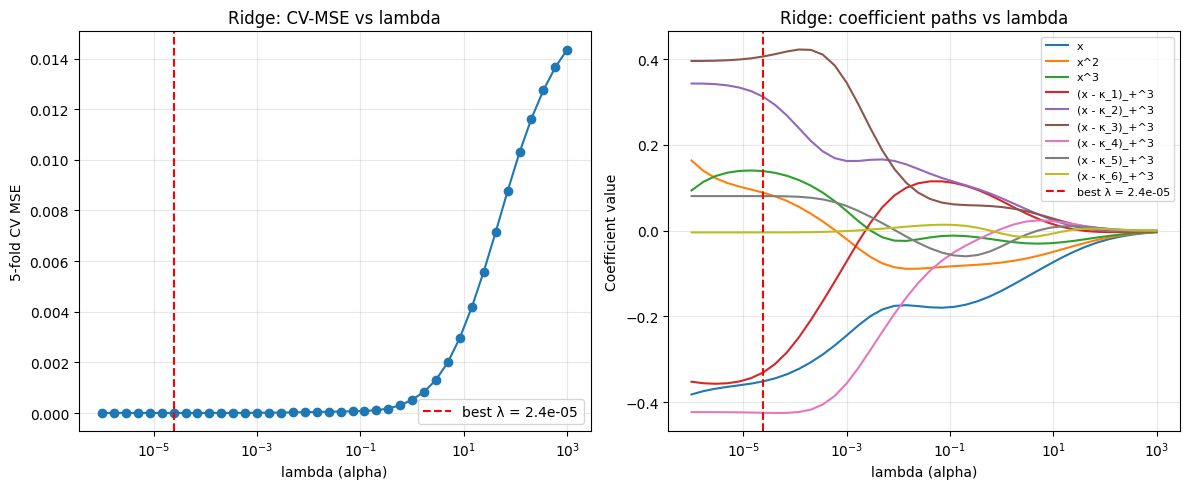

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge, LinearRegression

# ============================================================
# 1. Data + TPB design (k = 6, même que ton modèle best)
# ============================================================

newq = pd.read_csv("data/newquotes_.csv").sort_values(["maturity", "strike"])
T_target = 0.1

dfT = newq[newq["maturity"] == T_target].sort_values("strike")
x_train = dfT["strike"].values
y_train = dfT["implied_vol"].values

def tpb_cubic_design_no_const(x, knots):
    """
    TPB cubic sans constante :
    [x, x^2, x^3, (x-k1)+^3, ..., (x-kk)+^3]
    """
    x = np.asarray(x).ravel()
    cols = [x, x**2, x**3]
    for k in knots:
        cols.append(np.maximum(x - k, 0.0)**3)
    return np.column_stack(cols)

def make_knots_from_quantiles(x, k):
    if k <= 0:
        return []
    qs = np.linspace(0, 1, k+2)[1:-1]
    return list(np.quantile(x, qs))

k = 6
knots_6 = make_knots_from_quantiles(x_train, k)

X_train = tpb_cubic_design_no_const(x_train, knots_6)

# standardisation des features pour Ridge / OLS
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)

n, p_features = X_train_s.shape
p_params = p_features + 1   # + intercept

# ============================================================
# 2. Fonction de metrics (AIC + BIC + R2)
# ============================================================

def metrics_lin(y, yhat, p):
    n = len(y)
    resid = y - yhat
    rss = float(np.sum(resid**2))
    mse = rss / n
    sst = float(np.sum((y - np.mean(y))**2))

    R2 = 1 - rss/sst
    R2_adj = 1 - (1 - R2)*(n-1)/(n-p-1)

    # AIC/BIC up to constante
    eps = 1e-12
    AIC = n * np.log(mse + eps) + 2 * p
    BIC = n * np.log(mse + eps) + p * np.log(n)

    return {"MSE": mse, "AIC": AIC, "BIC": BIC, "R2": R2, "R2_adj": R2_adj}

# ============================================================
# 3. CV-MSE helper
# ============================================================

def cv_mse_model(model_ctor, X, y, **model_kwargs):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    mse_sum = 0.0
    for tr_idx, vl_idx in kf.split(X):
        X_tr, X_vl = X[tr_idx], X[vl_idx]
        y_tr, y_vl = y[tr_idx], y[vl_idx]
        model = model_ctor(**model_kwargs)
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_vl)
        mse_sum += np.mean((y_vl - y_hat)**2)
    return mse_sum / 5

# ============================================================
# 4. Base line : OLS (TPB cubic k=6, pas de pénalisation)
# ============================================================

ols = LinearRegression(fit_intercept=True)
ols.fit(X_train_s, y_train)
y_hat_ols = ols.predict(X_train_s)

ols_metrics = metrics_lin(y_train, y_hat_ols, p=p_params)
ols_cv_mse = cv_mse_model(LinearRegression, X_train_s, y_train, fit_intercept=True)

print("OLS (TPB k=6)")
print(ols_metrics, "CV-MSE:", ols_cv_mse, "\n")

# ============================================================
# 5. Ridge : grid sur lambda + courbes de coefficients
# ============================================================

alpha_grid = np.logspace(-6, 3, 40)

cv_mses = []
coef_paths = []

for alpha in alpha_grid:
    # CV-MSE pour ce lambda
    mse_cv = cv_mse_model(Ridge, X_train_s, y_train, alpha=alpha, fit_intercept=True)
    cv_mses.append(mse_cv)

    # Coefs sur tout le train
    ridge_full = Ridge(alpha=alpha, fit_intercept=True)
    ridge_full.fit(X_train_s, y_train)
    coef_paths.append(ridge_full.coef_)

cv_mses = np.array(cv_mses)
coef_paths = np.vstack(coef_paths)

best_idx = int(np.argmin(cv_mses))
best_alpha = alpha_grid[best_idx]
best_cv_mse = cv_mses[best_idx]

print(f"Best alpha (Ridge) = {best_alpha:.3e}, CV-MSE = {best_cv_mse:.6e}")

# Fit final Ridge sur tout le train avec alpha*
ridge_best = Ridge(alpha=best_alpha, fit_intercept=True)
ridge_best.fit(X_train_s, y_train)
y_hat_ridge = ridge_best.predict(X_train_s)

ridge_metrics = metrics_lin(y_train, y_hat_ridge, p=p_params)

print("Ridge (TPB k=6, alpha*):")
print(ridge_metrics, "\n")

# ============================================================
# 6. Tableau comparatif OLS vs Ridge
# ============================================================

summary = pd.DataFrame([
    {
        "Model": "OLS TPB k=6",
        "alpha": 0.0,
        "Train_MSE": ols_metrics["MSE"],
        "CV_MSE": ols_cv_mse,
        "AIC": ols_metrics["AIC"],
        "BIC": ols_metrics["BIC"],
        "R2": ols_metrics["R2"],
        "R2_adj": ols_metrics["R2_adj"],
    },
    {
        "Model": "Ridge TPB k=6",
        "alpha": best_alpha,
        "Train_MSE": ridge_metrics["MSE"],
        "CV_MSE": best_cv_mse,
        "AIC": ridge_metrics["AIC"],
        "BIC": ridge_metrics["BIC"],
        "R2": ridge_metrics["R2"],
        "R2_adj": ridge_metrics["R2_adj"],
    }
])

print("\n=== OLS vs Ridge (in-sample, T = 0.1) ===\n")
print(summary)

# ============================================================
# 7. Plots : CV-MSE & coefficient paths vs lambda
# ============================================================

feature_names = (
    ["x", "x^2", "x^3"] +
    [f"(x - κ_{j+1})_+^3" for j in range(k)]
)

plt.figure(figsize=(12,5))

# (a) CV-MSE vs lambda
plt.subplot(1,2,1)
plt.plot(alpha_grid, cv_mses, marker="o")
plt.axvline(best_alpha, color="red", linestyle="--", label=f"best λ = {best_alpha:.1e}")
plt.xscale("log")
plt.xlabel("lambda (alpha)")
plt.ylabel("5-fold CV MSE")
plt.title("Ridge: CV-MSE vs lambda")
plt.grid(True, alpha=0.3)
plt.legend()

# (b) chemins de coefficients
plt.subplot(1,2,2)
for j in range(p_features):
    plt.plot(alpha_grid, coef_paths[:, j], label=feature_names[j])

plt.axvline(best_alpha, color="red", linestyle="--", label=f"best λ = {best_alpha:.1e}")
plt.xscale("log")
plt.xlabel("lambda (alpha)")
plt.ylabel("Coefficient value")
plt.title("Ridge: coefficient paths vs lambda")
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()


OLS (TPB k=6)
  metrics: {'MSE': 1.622405618928576e-10, 'AIC': -1039.1824196736704, 'BIC': -1020.6809436565699, 'R2': 0.9999999351956312, 'R2_adj': 0.9999999171944177}
  CV-MSE : 2.930547532695406e-10 

Ridge (TPB k=6) best alpha = 1.000e-06
  metrics: {'MSE': 4.600741917538485e-10, 'AIC': -990.3807210181093, 'BIC': -971.8792450010087, 'R2': 0.9999998162308044, 'R2_adj': 0.9999997651838056}
  CV-MSE : 1.0374512932712877e-09 

LASSO (TPB k=6) best alpha = 1.000e-06
  metrics: {'MSE': 5.6488807854002975e-08, 'AIC': -764.3926635304641, 'BIC': -745.8911875133635, 'R2': 0.9999774364592333, 'R2_adj': 0.9999711688090204}
  CV-MSE : 8.596697888150051e-08 


=== OLS vs Ridge vs LASSO (in-sample, T = 0.1) ===

           Model     alpha     Train_MSE        CV_MSE          AIC  \
0    OLS TPB k=6  0.000000  1.622406e-10  2.930548e-10 -1039.182420   
1  Ridge TPB k=6  0.000001  4.600742e-10  1.037451e-09  -990.380721   
2  LASSO TPB k=6  0.000001  5.648881e-08  8.596698e-08  -764.392664   

     

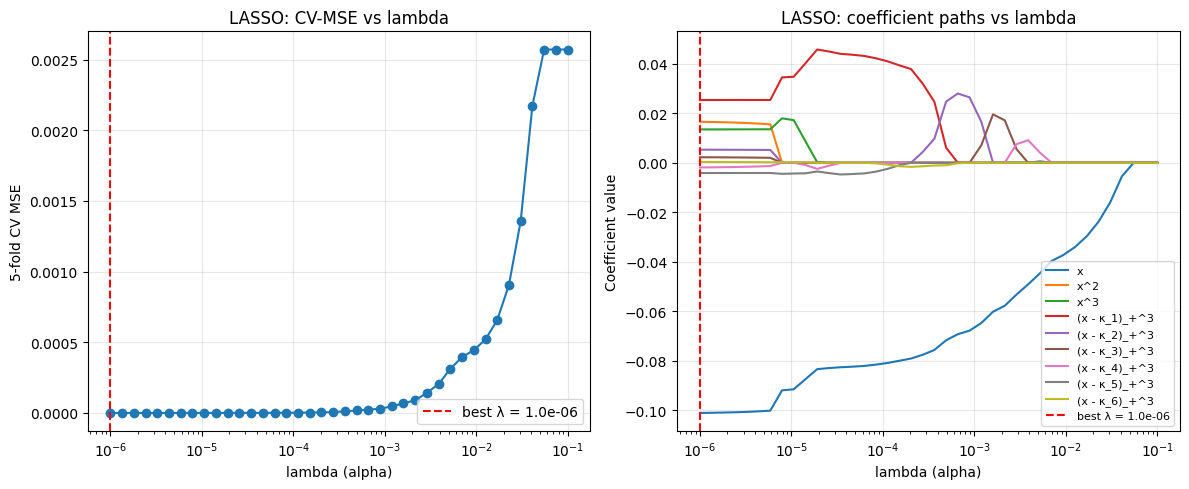

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge, Lasso, LinearRegression

# ============================================================
# 1. Data + TPB design (k = 6, même modèle que ton best)
# ============================================================

newq = pd.read_csv("data/newquotes_.csv").sort_values(["maturity", "strike"])
T_target = 2.0

dfT = newq[newq["maturity"] == T_target].sort_values("strike")
x_train = dfT["strike"].values
y_train = dfT["implied_vol"].values

def tpb_cubic_design_no_const(x, knots):
    """
    TPB cubic sans constante :
    [x, x^2, x^3, (x-k1)+^3, ..., (x-kk)+^3]
    """
    x = np.asarray(x).ravel()
    cols = [x, x**2, x**3]
    for k in knots:
        cols.append(np.maximum(x - k, 0.0)**3)
    return np.column_stack(cols)

def make_knots_from_quantiles(x, k):
    if k <= 0:
        return []
    qs = np.linspace(0, 1, k+2)[1:-1]
    return list(np.quantile(x, qs))

k = 6
knots_6 = make_knots_from_quantiles(x_train, k)

X_train = tpb_cubic_design_no_const(x_train, knots_6)

# standardisation des features pour tous les modèles
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)

n, p_features = X_train_s.shape
p_params = p_features + 1   # + intercept

feature_names = (
    ["x", "x^2", "x^3"] +
    [f"(x - κ_{j+1})_+^3" for j in range(k)]
)

# ============================================================
# 2. Metrics (MSE, AIC, BIC, R2, R2_adj)
# ============================================================

def metrics_lin(y, yhat, p):
    n = len(y)
    resid = y - yhat
    rss = float(np.sum(resid**2))
    mse = rss / n
    sst = float(np.sum((y - np.mean(y))**2))

    R2 = 1 - rss/sst
    R2_adj = 1 - (1 - R2)*(n-1)/(n-p-1)

    eps = 1e-12
    AIC = n * np.log(mse + eps) + 2 * p
    BIC = n * np.log(mse + eps) + p * np.log(n)

    return {"MSE": mse, "AIC": AIC, "BIC": BIC, "R2": R2, "R2_adj": R2_adj}

def cv_mse_model(model_ctor, X, y, **model_kwargs):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    mse_sum = 0.0
    for tr_idx, vl_idx in kf.split(X):
        X_tr, X_vl = X[tr_idx], X[vl_idx]
        y_tr, y_vl = y[tr_idx], y[vl_idx]
        model = model_ctor(**model_kwargs)
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_vl)
        mse_sum += np.mean((y_vl - y_hat)**2)
    return mse_sum / 5

# ============================================================
# 3. OLS (baseline)
# ============================================================

ols = LinearRegression(fit_intercept=True)
ols.fit(X_train_s, y_train)
y_hat_ols = ols.predict(X_train_s)

ols_metrics = metrics_lin(y_train, y_hat_ols, p=p_params)
ols_cv_mse = cv_mse_model(LinearRegression, X_train_s, y_train, fit_intercept=True)

print("OLS (TPB k=6)")
print("  metrics:", ols_metrics)
print("  CV-MSE :", ols_cv_mse, "\n")

# ============================================================
# 4. Ridge (déjà fait mais on le garde pour comparaison)
# ============================================================

alpha_grid_ridge = np.logspace(-6, 3, 40)

cv_mses_ridge = []
coef_paths_ridge = []

for alpha in alpha_grid_ridge:
    mse_cv = cv_mse_model(Ridge, X_train_s, y_train,
                          alpha=alpha, fit_intercept=True)
    cv_mses_ridge.append(mse_cv)

    ridge_full = Ridge(alpha=alpha, fit_intercept=True)
    ridge_full.fit(X_train_s, y_train)
    coef_paths_ridge.append(ridge_full.coef_)

cv_mses_ridge = np.array(cv_mses_ridge)
coef_paths_ridge = np.vstack(coef_paths_ridge)

best_idx_r = int(np.argmin(cv_mses_ridge))
best_alpha_r = alpha_grid_ridge[best_idx_r]
best_cv_mse_r = cv_mses_ridge[best_idx_r]

ridge_best = Ridge(alpha=best_alpha_r, fit_intercept=True)
ridge_best.fit(X_train_s, y_train)
y_hat_ridge = ridge_best.predict(X_train_s)

ridge_metrics = metrics_lin(y_train, y_hat_ridge, p=p_params)

print(f"Ridge (TPB k=6) best alpha = {best_alpha_r:.3e}")
print("  metrics:", ridge_metrics)
print("  CV-MSE :", best_cv_mse_r, "\n")

# ============================================================
# 5. LASSO : grid sur lambda + chemins des coefficients
# ============================================================

alpha_grid_lasso = np.logspace(-6, -1, 40)  # plus petit max pour éviter tout zéro trop tôt

cv_mses_lasso = []
coef_paths_lasso = []

for alpha in alpha_grid_lasso:
    mse_cv = cv_mse_model(Lasso, X_train_s, y_train,
                          alpha=alpha, fit_intercept=True, max_iter=100000)
    cv_mses_lasso.append(mse_cv)

    lasso_full = Lasso(alpha=alpha, fit_intercept=True, max_iter=100000)
    lasso_full.fit(X_train_s, y_train)
    coef_paths_lasso.append(lasso_full.coef_)

cv_mses_lasso = np.array(cv_mses_lasso)
coef_paths_lasso = np.vstack(coef_paths_lasso)

best_idx_l = int(np.argmin(cv_mses_lasso))
best_alpha_l = alpha_grid_lasso[best_idx_l]
best_cv_mse_l = cv_mses_lasso[best_idx_l]

lasso_best = Lasso(alpha=best_alpha_l, fit_intercept=True, max_iter=100000)
lasso_best.fit(X_train_s, y_train)
y_hat_lasso = lasso_best.predict(X_train_s)

lasso_metrics = metrics_lin(y_train, y_hat_lasso, p=p_params)

print(f"LASSO (TPB k=6) best alpha = {best_alpha_l:.3e}")
print("  metrics:", lasso_metrics)
print("  CV-MSE :", best_cv_mse_l, "\n")

# ============================================================
# 6. Tableau comparatif OLS / Ridge / LASSO
# ============================================================

summary = pd.DataFrame([
    {
        "Model": "OLS TPB k=6",
        "alpha": 0.0,
        "Train_MSE": ols_metrics["MSE"],
        "CV_MSE": ols_cv_mse,
        "AIC": ols_metrics["AIC"],
        "BIC": ols_metrics["BIC"],
        "R2": ols_metrics["R2"],
        "R2_adj": ols_metrics["R2_adj"],
    },
    {
        "Model": "Ridge TPB k=6",
        "alpha": best_alpha_r,
        "Train_MSE": ridge_metrics["MSE"],
        "CV_MSE": best_cv_mse_r,
        "AIC": ridge_metrics["AIC"],
        "BIC": ridge_metrics["BIC"],
        "R2": ridge_metrics["R2"],
        "R2_adj": ridge_metrics["R2_adj"],
    },
    {
        "Model": "LASSO TPB k=6",
        "alpha": best_alpha_l,
        "Train_MSE": lasso_metrics["MSE"],
        "CV_MSE": best_cv_mse_l,
        "AIC": lasso_metrics["AIC"],
        "BIC": lasso_metrics["BIC"],
        "R2": lasso_metrics["R2"],
        "R2_adj": lasso_metrics["R2_adj"],
    }
])

print("\n=== OLS vs Ridge vs LASSO (in-sample, T = 0.1) ===\n")
print(summary)

# ============================================================
# 7. Plots : CV-MSE & coeff paths pour LASSO (style de ta figure)
# ============================================================

plt.figure(figsize=(12,5))

# (a) CV-MSE vs lambda (LASSO)
plt.subplot(1,2,1)
plt.plot(alpha_grid_lasso, cv_mses_lasso, marker="o")
plt.axvline(best_alpha_l, color="red", linestyle="--",
            label=f"best λ = {best_alpha_l:.1e}")
plt.xscale("log")
plt.xlabel("lambda (alpha)")
plt.ylabel("5-fold CV MSE")
plt.title("LASSO: CV-MSE vs lambda")
plt.grid(True, alpha=0.3)
plt.legend()

# (b) chemins de coefficients (LASSO)
plt.subplot(1,2,2)
for j in range(p_features):
    plt.plot(alpha_grid_lasso, coef_paths_lasso[:, j], label=feature_names[j])

plt.axvline(best_alpha_l, color="red", linestyle="--",
            label=f"best λ = {best_alpha_l:.1e}")
plt.xscale("log")
plt.xlabel("lambda (alpha)")
plt.ylabel("Coefficient value")
plt.title("LASSO: coefficient paths vs lambda")
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()
